## Brazilian E-Commerce

Este proyecto utiliza un conjunto de datos público de comercio electrónico brasileño que contiene información de aproximadamente 100,000 pedidos realizados entre 2016 y 2018 en múltiples marketplaces. El dataset integra distintas dimensiones del proceso de compra, incluyendo el estado de los pedidos, precios, métodos de pago, costos y tiempos de envío, así como la ubicación de los clientes, atributos de los productos y reseñas generadas por los usuarios.


El objetivo de este proyecto es analizar el desempeño del comercio electrónico desde distintas perspectivas clave del negocio:

**Logística**: evaluar el cumplimiento en los tiempos de entrega, identificando retrasos y su frecuencia.

**Ventas**: identificar las principales fuentes de ingresos, incluyendo categorías de productos, precios y patrones de compra.

**Reseñas** (Reviews): analizar los factores que influyen en la satisfacción del cliente, considerando calificaciones y comentarios.

**Clientes**: segmentar y caracterizar a los clientes para determinar quiénes generan mayor valor en términos de compras.

A partir de este análisis, se busca detectar patrones, relaciones y oportunidades de mejora que contribuyan a optimizar la operación y la experiencia del cliente.

Importar paqueterias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importar tablas de datos

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv', parse_dates=['review_creation_date', 'review_answer_timestamp'])
fact_order = pd.read_csv('olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_name = pd.read_csv('product_category_name_translation.csv')

Limpieza de datos

se volvio a traer las tablas fact_order, order_items, order_reviews para cambiar todos las columnas de fecha a tipo datetime64

In [3]:
fact_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [4]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [5]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


se revisan las demas tablas si tienen valores nulos o errores 

In [6]:
order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [8]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [10]:
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [12]:
sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [13]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [14]:
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [15]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


**Analisis de Logística**: cumplimiento en los tiempos de entrega, identificando retrasos y su frecuencia.

In [79]:
fact_order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,9 days 10:48:43,-13.0,False,early,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1 days 22:30:28,-10.0,False,early,delivered


Se crea una columna para el tiempo que se tardo en entregar el paquete

In [80]:
fact_order['delivered_time'] = fact_order['order_delivered_customer_date'] - fact_order['order_delivered_carrier_date']

Se crea una columna para ver cuantos dias tiene de retraso el paquete si es el caso

In [81]:
fact_order['delay_days'] = (fact_order['order_delivered_customer_date'] - fact_order['order_estimated_delivery_date']).dt.days

despues se crea una columna con las categorias segun el tiempo de retraso que tengan

In [82]:
def delay_category(x):
    if pd.isna(x):
        return np.nan
    elif x > 3:
        return 'late'
    elif x > 0:
        return 'slightly_late'
    elif x == 0:
        return 'on_time'
    else:
        return 'early'

fact_order['delay_category'] = fact_order['delay_days'].apply(delay_category)

In [83]:
fact_order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,9 days 10:48:43,-13.0,False,early,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1 days 22:30:28,-10.0,False,early,delivered


In [84]:
fact_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  object         
 1   customer_id                    99441 non-null  object         
 2   order_status                   99441 non-null  object         
 3   order_purchase_timestamp       99441 non-null  datetime64[ns] 
 4   order_approved_at              99281 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns] 
 6   order_delivered_customer_date  96476 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns] 
 8   delivered_time                 96475 non-null  timedelta64[ns]
 9   delay_days                     96476 non-null  float64        
 10  is_delayed                     99441 non-null  bool           
 11  de

In [85]:
fact_order['delay_category'] = fact_order['delay_category'].astype('category')

In [86]:
fact_order.groupby('delay_category', observed=True).size()

delay_category
early            88649
late              4665
on_time           1292
slightly_late     1870
dtype: int64

Se muestra la distribución de los dias de retraso

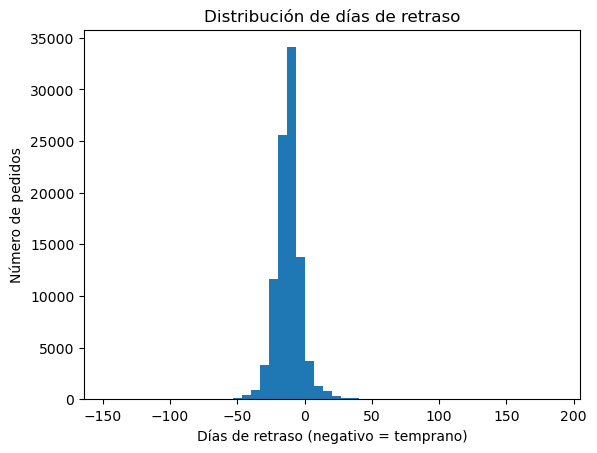

In [87]:
plt.hist(fact_order['delay_days'], bins=50)
plt.title('Distribución de días de retraso')
plt.xlabel('Días de retraso (negativo = temprano)')
plt.ylabel('Número de pedidos')
plt.show()

In [88]:
fact_order[fact_order['delay_days'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,NaT,NaN,False,NaN,no_delivery
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28,NaT,NaN,False,NaN,no_delivery
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,NaT,NaN,False,NaN,no_delivery
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,NaT,NaN,False,NaN,no_delivery
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07,NaT,NaN,False,NaN,no_delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01,NaT,NaN,False,NaN,no_delivery
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06,NaT,NaN,False,NaN,no_delivery
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27,NaT,NaN,False,NaN,no_delivery
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15,NaT,NaN,False,NaN,no_delivery


Se realiza una grafica para ver segun la categoria de retraso

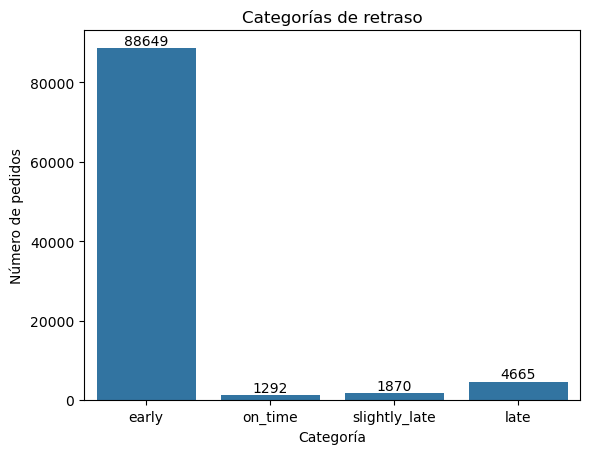

In [89]:
orden = ['early', 'on_time', 'slightly_late', 'late']

plt.figure()
ax = sns.countplot(x='delay_category', data=fact_order, order=orden)

# etiquetas
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Categorías de retraso')
plt.xlabel('Categoría')
plt.ylabel('Número de pedidos')
plt.show()

Creo una nueva columna para ver cuatos paquetes si fueron entregados y cuantos no 

In [90]:
fact_order['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [91]:
fact_order['delivery_status'] = fact_order['order_status'].apply(
    lambda x: 'delivered' if x == 'delivered' else 'no_delivery'
)


In [92]:
fact_order['delivery_status'].unique()

array(['delivered', 'no_delivery'], dtype=object)

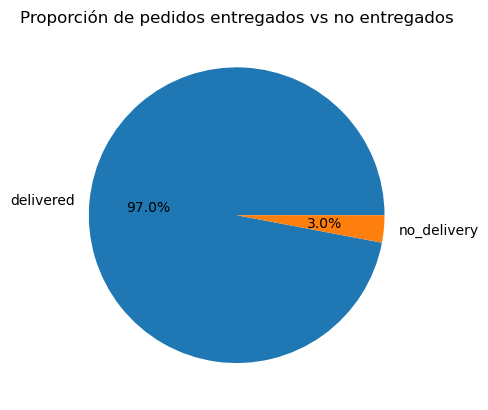

In [93]:
conteo = fact_order['delivery_status'].value_counts()

plt.figure()
plt.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%')
plt.title('Proporción de pedidos entregados vs no entregados')
plt.show()

**Analisis de Reseñas** (Reviews): analizar los factores que influyen en la satisfacción del cliente, considerando calificaciones y comentarios.

In [94]:
order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [95]:
fact_review = fact_order.merge(order_reviews, on = 'order_id', how ='left')

In [96]:
fact_review.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,9 days 10:48:43,-13.0,False,early,delivered,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1 days 22:30:28,-10.0,False,early,delivered,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17,2018-02-18 13:02:51


In [97]:
fact_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99992 non-null  object         
 1   customer_id                    99992 non-null  object         
 2   order_status                   99992 non-null  object         
 3   order_purchase_timestamp       99992 non-null  datetime64[ns] 
 4   order_approved_at              99831 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns] 
 6   order_delivered_customer_date  97005 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns] 
 8   delivered_time                 97004 non-null  timedelta64[ns]
 9   delay_days                     97005 non-null  float64        
 10  is_delayed                     99992 non-null  bool           
 11  de

Se crea una grafica para ver como afecta la tardansa del pedido para la calificacion de la review

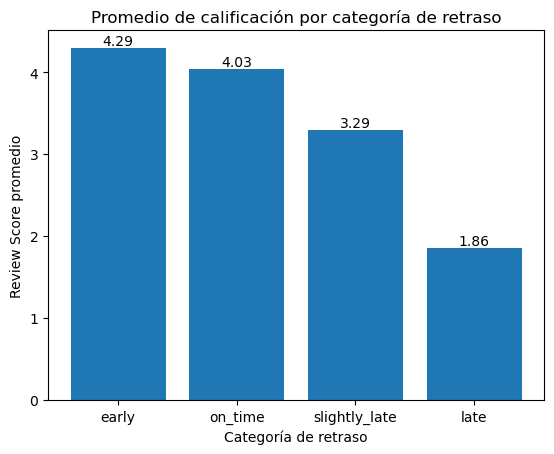

In [98]:
data = fact_review.groupby('delay_category', observed=True)['review_score'].mean()

orden = ['early', 'on_time', 'slightly_late', 'late']
data = data.reindex(orden)

plt.figure()
bars = plt.bar(data.index, data.values)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Promedio de calificación por categoría de retraso')
plt.xlabel('Categoría de retraso')
plt.ylabel('Review Score promedio')
plt.show()

In [99]:
order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [100]:
fact_payments = fact_order.merge(order_payments, on = 'order_id', how ='left')

In [101]:
fact_payments.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered,1.0,credit_card,3.0,179.12


In [102]:
fact_payments.groupby('payment_type')['payment_installments'].mean()

payment_type
boleto         1.000000
credit_card    3.507155
debit_card     1.000000
not_defined    1.000000
voucher        1.000000
Name: payment_installments, dtype: float64

In [103]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Analisis de Ventas**: identificar las principales fuentes de ingresos, incluyendo categorías de productos, precios y patrones de compra.

In [104]:
fact_order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,9 days 10:48:43,-13.0,False,early,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1 days 22:30:28,-10.0,False,early,delivered


In [105]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [106]:
sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [107]:
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [108]:
products_fact = order_items[['order_id','order_item_id', 'product_id', 'seller_id', 'price', 'freight_value']].merge(products[['product_id', 'product_category_name']], on ='product_id', how='left').merge(sellers, on = 'seller_id', how = 'left').merge(category_name, on='product_category_name', how='left')

In [109]:
products_fact.head(5)

,order_id,order_item_id,product_id,seller_id,price,freight_value,product_category_name,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff,27277,volta redonda,SP,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop,3471,sao paulo,SP,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,moveis_decoracao,37564,borda da mata,MG,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumaria,14403,franca,SP,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,ferramentas_jardim,87900,loanda,PR,garden_tools


productos con mas ingresos

In [110]:
products_fact.groupby('product_id')['price'].sum().sort_values(ascending = False).head(10)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64

productos mas vendidos por cantidad

In [111]:
products_fact.groupby('product_id')['price'].count().sort_values(ascending = False).head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: price, dtype: int64

categorias que generan mas Ingresos 

In [112]:
products_fact.groupby('product_category_name_english')['price'].sum().sort_values(ascending= False).head(10).sum()

np.float64(8475957.56)

In [113]:
products_fact['price'].sum()

np.float64(13591643.7)

grafica para ver que categorias generan mas ingresos

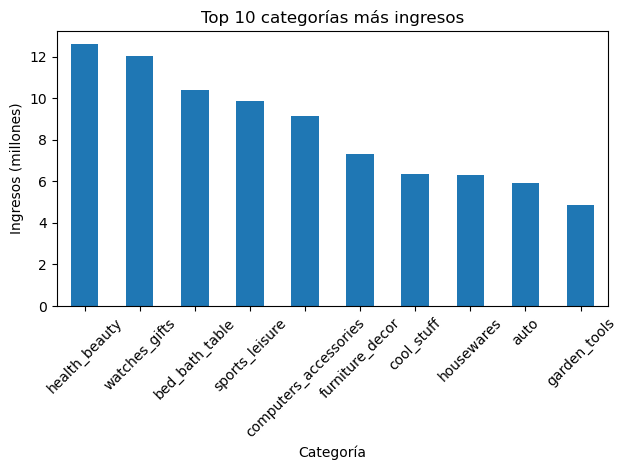

In [114]:
categorias_con_ingresos = products_fact.groupby('product_category_name_english')['price'].sum().sort_values(ascending= False).head(10) / 100000

ax= categorias_con_ingresos.plot(kind='bar')

plt.title('Top 10 categorías más ingresos')
plt.xlabel('Categoría')
plt.ylabel('Ingresos (millones)')

plt.xticks(rotation=45)
plt.tight_layout()

categorias mas vendidas por cantidad

In [135]:
categorias_mas_vendidas = products_fact.groupby('product_category_name_english').size().sort_values(ascending= False).head(10)

In [136]:
categorias_mas_vendidas.sum()

np.int64(71669)

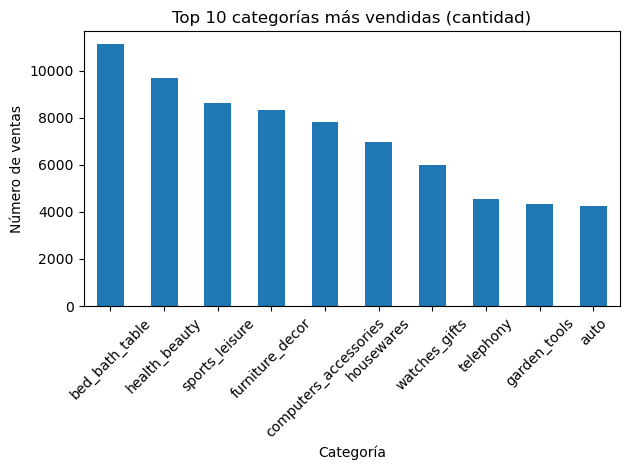

In [134]:
categorias_mas_vendidas = products_fact.groupby('product_category_name_english').size().sort_values(ascending= False).head(10)

categorias_mas_vendidas.plot(kind='bar')

plt.title('Top 10 categorías más vendidas (cantidad)')
plt.xlabel('Categoría')
plt.ylabel('Número de ventas')
plt.xticks(rotation=45)
plt.tight_layout()


vendedores que mas productos venden 

In [117]:
products_fact.groupby('seller_id')['price'].count().sort_values(ascending= False).head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: price, dtype: int64

vendedores que mas ingresos genera

In [118]:
products_fact.groupby('seller_id')['price'].sum().sort_values(ascending= False).head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

los pedidos con mas ingresos que hemos tenido 

In [119]:
products_fact.groupby('order_id')['price'].sum().sort_values(ascending= False).head(10)

order_id
03caa2c082116e1d31e67e9ae3700499    13440.0
736e1922ae60d0d6a89247b851902527     7160.0
0812eb902a67711a1cb742b3cdaa65ae     6735.0
fefacc66af859508bf1a7934eab1e97f     6729.0
f5136e38d1a14a4dbd87dff67da82701     6499.0
2cc9089445046817a7539d90805e6e5a     5934.6
a96610ab360d42a2e5335a3998b4718a     4799.0
199af31afc78c699f0dbf71fb178d4d4     4690.0
b4c4b76c642808cbe472a32b86cddc95     4599.9
8dbc85d1447242f3b127dda390d56e19     4590.0
Name: price, dtype: float64

**Analisis de Clientes**: segmentar y caracterizar a los clientes para determinar quiénes generan mayor valor en términos de compras.

¿Quién compra más?

In [120]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [121]:
fact_order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delay_days,is_delayed,delay_category,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,6 days 01:30:13,-8.0,False,early,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,12 days 00:56:45,-6.0,False,early,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 04:16:29,-18.0,False,early,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,9 days 10:48:43,-13.0,False,early,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1 days 22:30:28,-10.0,False,early,delivered


In [122]:
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


limpieza de datos en geolocation

In [126]:
geolocation['geolocation_city'].unique()

array(['sao paulo', 'sao bernardo do campo', 'jundiaí', ..., 'ciríaco',
       'estação', 'vila lângaro'], shape=(8009,), dtype=object)

In [123]:
geolocation['geolocation_city'] = geolocation['geolocation_city'].replace('são paulo', 'sao paulo')

In [124]:
geolocation['geolocation_city'] = geolocation['geolocation_city'].replace('vianópolis', 'vianopolis')

de donde son la mayoria de los clientes 

In [125]:
customer_fact = fact_order[['order_id', 'customer_id', 'delivery_status', 'delay_category']].merge(customers, on='customer_id', how='left').merge(geolocation[['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']], right_on='geolocation_zip_code_prefix', left_on='customer_zip_code_prefix', how='left')

In [144]:
customer_fact['customer_id'].count()

np.int64(15083733)

In [143]:
customer_fact.groupby('customer_city').size().sort_values(ascending = False).head(10)

customer_city
rio de janeiro    1913966
sao paulo         1372376
belo horizonte     737548
niteroi            452857
curitiba           255744
santos             238952
porto alegre       228824
uberlandia         191192
campinas           170318
santo andre        167082
dtype: int64

Text(0, 0.5, 'numero de clientes (millones)')

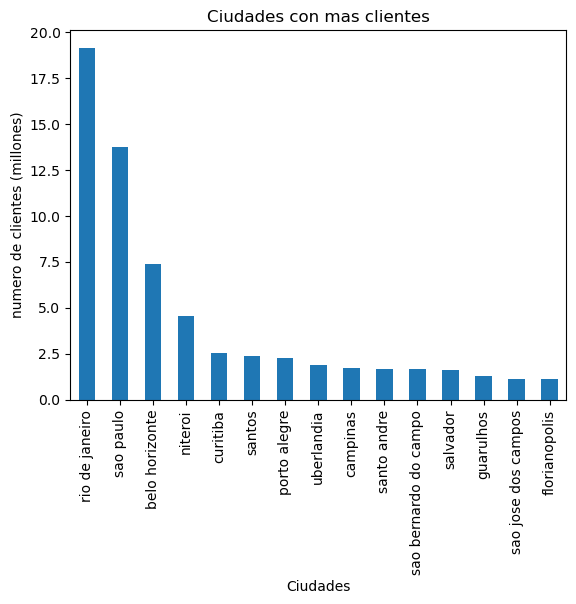

In [139]:
customer_city_fact = customer_fact.groupby('customer_city').size().sort_values(ascending = False).head(15) / 100000

customer_city_fact.plot(kind='bar')

plt.title('Ciudades con mas clientes')
plt.xlabel('Ciudades')
plt.ylabel('numero de clientes (millones)')


In [66]:
customer_fact.groupby('customer_state').size().sort_values(ascending = False).head(10)

customer_state
SP    5620465
RJ    3015722
MG    2878739
RS     805363
PR     626046
SC     538624
BA     365884
ES     316660
GO     133160
MT     122402
dtype: int64

Text(0, 0.5, 'numero de clientes (millones)')

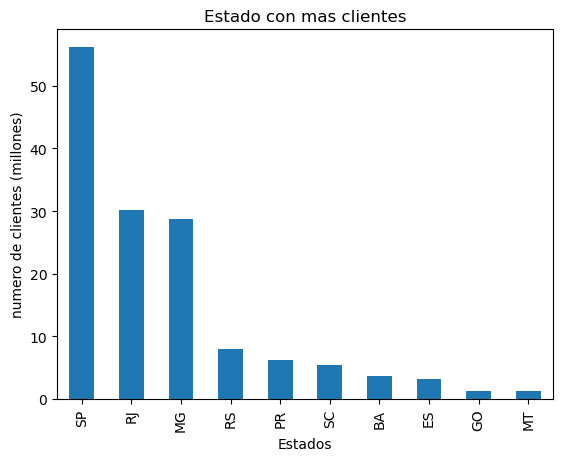

In [130]:
customer_state_fact = customer_fact.groupby('customer_state').size().sort_values(ascending = False).head(10) / 100000

customer_state_fact.plot(kind='bar')

plt.title('Estado con mas clientes')
plt.xlabel('Estados')
plt.ylabel('numero de clientes (millones)')

In [68]:
customer_fact.groupby('customer_zip_code_prefix').size().sort_values(ascending = False).head(10)

customer_zip_code_prefix
24220    142104
24230    128934
22790     97554
38400     83955
35500     78002
22631     74048
11680     66804
35162     66309
29101     63731
11740     63040
dtype: int64

In [70]:
customer_fact[customer_fact['customer_city'] != customer_fact['geolocation_city']]

,order_id,customer_id,delivery_status,delay_category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state
73,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,early,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,são gonçalo do amarante,RN
74,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,early,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,são gonçalo do amarante,RN
83,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,early,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,são gonçalo do amarante,RN
85,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,early,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,são gonçalo do amarante,RN
88,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,early,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9195.0,santo andré,SP
...,...,...,...,...,...,...,...,...,...,...,...
15083556,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,early,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,45920.0,nova viçosa,BA
15083573,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,early,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,28685.0,japuíba,RJ
15083575,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,early,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,28685.0,cachoeiras de macacu,RJ
15083576,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,early,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,28685.0,cachoeiras de macacu,RJ


lugar donde no llegen los paquetes

In [73]:
not_deliver = customer_fact[customer_fact['delivery_status'] == 'no_delivery']

In [74]:
not_deliver.groupby('customer_city').size().sort_values(ascending = False).head(10)

customer_city
rio de janeiro    71040
sao paulo         42332
belo horizonte    17772
niteroi           14900
porto alegre       5149
curitiba           4893
itanhaem           4728
guarulhos          4655
divinopolis        4535
salvador           4423
dtype: int64

In [76]:
not_deliver.groupby('customer_state').size().sort_values(ascending = False).head(10)

customer_state
SP    162398
RJ    108208
MG     69211
RS     16155
PR     15870
SC     15409
BA     10936
ES      5298
GO      3829
PE      3510
dtype: int64

In [78]:
not_deliver[not_deliver['customer_state'] != not_deliver['geolocation_state']]

,order_id,customer_id,delivery_status,delay_category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state
516666,e2f630b53cb2637be372c3810b089868,67f3e907dce402e696b15f9308ff22ed,no_delivery,NaN,6f232f2f5c7f33b7bd9d794d2afacadd,68629,paragominas,PA,NaN,NaN,NaN
1404069,dba5062fbda3af4fb6c33b1e040ca38f,964a6df3d9bdf60fe3e7b8bb69ed893a,no_delivery,NaN,2e015e68fbfa36910263df5384e8e45c,73401,brasilia,DF,NaN,NaN,NaN
2236354,2ee460773e708be4e0208745a3864b8c,3bd12f7c1ad3a3908905785e43de8603,no_delivery,NaN,2e5fb502adb87cf265468f4d2096d724,65137,maioba,MA,NaN,NaN,NaN
2611317,a0c1b0545665f839199e53177bc639f7,866945c325644a98b1356b2b50663c05,no_delivery,NaN,d7c46dd9b81066e7f37c294108188c8b,80630,curitiba,PR,80630.0,balneario de picarras,SC
2943804,e928f5fbefb30f228db4678d9222b231,950863681cb2112651ef0782da4e689d,no_delivery,NaN,11cb11ff52cc1e191282a0a3c1e03aa3,80630,curitiba,PR,80630.0,balneario de picarras,SC
3722746,eda3cb37479a52de9848bfba4b805cdf,6a511c608ca737b62ce160178b17ca5f,no_delivery,NaN,58f9481a6d59f6ff267e4cdfcd8251be,71996,brasilia,DF,NaN,NaN,NaN
4583627,db04082694e24f9e426fd68f516b46a3,79298f6a8720081178c7741e3eff8216,no_delivery,NaN,7ef7e4cd493353520fe3df708dc1cf07,13307,itu,SP,NaN,NaN,NaN
4764048,8300640f8328abe9ac6691e4caf3c2bf,1e0918f0d58bd46e2465857831ec892c,no_delivery,NaN,f0659077678fd05b5346a8afbf216c16,72280,brasilia,DF,NaN,NaN,NaN
8289240,04b8c60eb3cceaecde917716daa30bde,a6a3ccd6981f76577a6cfcac362430b2,no_delivery,NaN,815392b735eba3589a02408bce170947,72002,brasilia,DF,NaN,NaN,NaN
8452606,9c94a4ea2f7876660fa6f1b59b69c8e6,22e922696a7d1ab9a19c6b702fedc387,no_delivery,NaN,b030929cf3b8c3370ea8c611f9ccb32e,71905,brasilia,DF,NaN,NaN,NaN


# Principales hallazgos

**Logística**  
Se evalúa el cumplimiento en los tiempos de entrega, identificando retrasos y su frecuencia.  
La mayoría de los pedidos se entrega en tiempo o incluso antes de lo previsto; únicamente el **6.7% presenta retrasos**. Además, solo el **3% de los pedidos no llega a completarse**, lo que indica un alto nivel de cumplimiento logístico.

**Reseñas (Reviews)**  
Se analizan los factores que influyen en la satisfacción del cliente, considerando calificaciones y comentarios.  
Se observa que el **tiempo de entrega es el principal determinante de la satisfacción**, especialmente cuando los retrasos superan los **3 días**, lo que impacta negativamente en las calificaciones.

**Ventas**  
Se identifican las principales fuentes de ingresos, incluyendo categorías de productos, precios y patrones de compra.  
Se detecta una **alta concentración de ventas**, donde el **top 10 de vendedores genera el 74% de los ingresos**, lo que sugiere una fuerte dependencia en un grupo reducido de proveedores.

**Clientes**  
Se segmenta y caracteriza a los clientes para determinar quiénes generan mayor valor en términos de compras.  
Si bien la base de clientes se encuentra ampliamente distribuida geográficamente, se identifican ciertas concentraciones relevantes en ciudades como **Rio de Janeiro**, **São Paulo**, **Belo Horizonte** y **Niterói**. No obstante, la distribución general sigue siendo dispersa, sin una dependencia marcada en una sola región.

# Recomendaciones

**Logística**  
- Implementar alertas tempranas para pedidos con riesgo de retraso (por ejemplo, cuando se aproximen a la fecha límite de entrega).  
- Analizar las causas raíz de los retrasos (operación, transporte, ubicación) para aplicar mejoras específicas.  

**Reseñas (Reviews)**  
- Priorizar la reducción de tiempos de entrega, especialmente evitando retrasos mayores a 3 días.  
- Implementar comunicación proactiva con el cliente ante posibles retrasos (notificaciones y seguimiento).  

**Ventas**  
- Diversificar la base de vendedores para reducir la dependencia del top 10.  
- Identificar prácticas exitosas de los vendedores líderes y replicarlas en otros vendedores.  
- Diseñar estrategias de promoción para vendedores con bajo desempeño y alto potencial.  

**Clientes**  
- Enfocar estrategias de marketing y retención en ciudades clave como **Rio de Janeiro**, **São Paulo**, **Belo Horizonte** y **Niterói**, donde se observa mayor concentración de clientes.     
- Identificar regiones con mayor potencial de crecimiento y enfocar esfuerzos comerciales en ellas.  